In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertModel, BertTokenizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import scipy.sparse as sparse
from scipy.spatial.distance import pdist
import glob
import networkx as nx
from importlib import reload
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from sklearn.metrics import mean_squared_error

import anndata as an
import scanpy as sc
import scanpy.external as sce
import phate

# locals
import cellnet as cn
import nextcell as nc

/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Class build

/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


input_data.shape=torch.Size([1, 100])
target_data.shape=torch.Size([1, 100])
predicted.shape=torch.Size([1, 100])


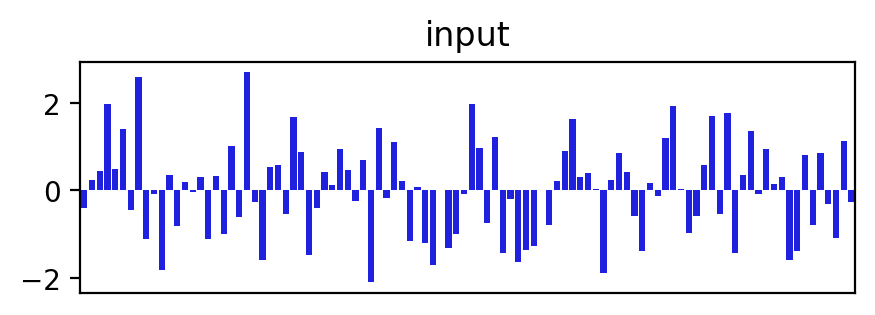

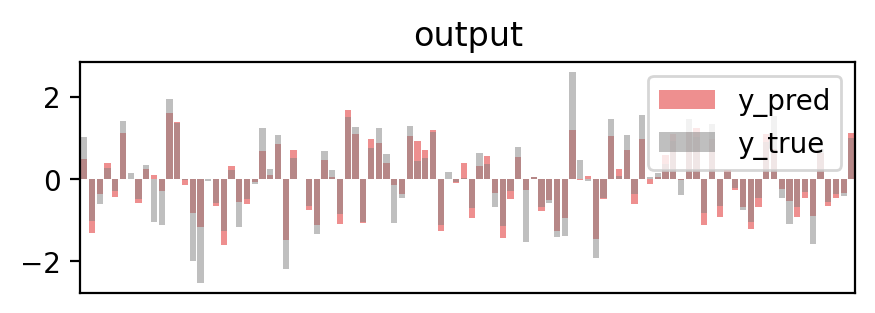

In [2]:
# Example usage
input_size = 100
hidden_size = 128
output_size = 100
batch_size = 1

model = nc.NextCell(input_size, hidden_size, output_size)
input_data = torch.randn(batch_size, input_size)
target_data = torch.randn(batch_size, output_size)

print(f"{input_data.shape=}")
print(f"{target_data.shape=}")

# Training the model
training_history = model.train_model(input_data, target_data, epochs=10)
predicted = model.predict(input_data)
print(f"{predicted.shape=}")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 1.5

sns.barplot(
    input_data,
    color='blue',
)
plt.xticks([])
plt.title('input')
plt.show()

sns.barplot(
    predicted.detach().numpy(),
    color='r',
    label='y_pred',
    alpha=0.5,
)

sns.barplot(
    target_data,
    color='grey',
    label='y_true',
    alpha=0.5,
)

plt.xticks([])
plt.title('output')
plt.legend()
plt.show()

# Real data

In [3]:
# """ CZI HSCS """
# dpath = "/nfs/turbo/umms-indikar/shared/projects/czi_projects/data/hsc_anndata/"

# file_list = glob.glob(f"{dpath}*")
# adata = sc.read_h5ad(file_list[0])

# """ SUBSAMPLING """
# fraction = 0.25
# adata = sc.pp.sample(adata, fraction=fraction, copy=True)

# adata

In [4]:
""" TABULA SAPIENS BLOOD """
fpath = "/nfs/turbo/umms-indikar/shared/projects/DGC/data/tabula_sapiens/extract/TS_Blood.h5ad"
adata = sc.read_h5ad(fpath)
adata.obs['cell_type'] = adata.obs['free_annotation']
adata.obs['tissue'] = adata.obs['organ_tissue']
adata.X = adata.layers['raw_counts']

""" SUBSAMPLING """
fraction = 0.25
adata = sc.pp.sample(adata, fraction=fraction, copy=True)

adata

AnnData object with n_obs × n_vars = 12528 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'cell_type', 'tissue'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [5]:
adata.obs.head()

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,cell_type,tissue
cell_id,,,,,,,,,,,,,
GGTTAACAGTAGTCCT_TSP10_Blood_NA_10X_2_1_Whole,Blood,10X,TSP10,nan,11066.0,2598,"cd8-positive, alpha-beta t cell","cd8-positive, alpha-beta t cell",True,immune,male,"cd8-positive, alpha-beta t cell",Blood
ATGACCATCCTCTCTT_TSP7_Blood_NA_10X_1_1,Blood,10X,TSP7,nan,25899.0,5481,t cell,alpha beta T cell,True,immune,female,alpha beta T cell,Blood
GGTAACTTCAGCTTCC_TSP14_Blood_NA_10X_2_1,Blood,10X,TSP14,nan,3132.0,1472,classical monocyte,classical monocyte,True,immune,male,classical monocyte,Blood
GATGAGGCATGTCGTA_TSP7_Blood_NA_10X_2_1,Blood,10X,TSP7,nan,16472.0,376,erythrocyte,erythrocyte,True,immune,female,erythrocyte,Blood
CGCGTGACATAAGATG_TSP10_Blood_NA_10X_1_1_Whole,Blood,10X,TSP10,nan,17959.0,4433,basophil,basophil,True,immune,male,basophil,Blood


# Simple Clean-Up

In [6]:
sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_counts=50)

adata.layers['raw'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata

AnnData object with n_obs × n_vars = 12528 × 20660
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'cell_type', 'tissue', 'n_counts'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'umap', 'log1p'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts', 'raw'
    obsp: 'connectivities', 'distances'

/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:306: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:415: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)
/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:306: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:415: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)
/home/cstansbu/miniconda3/envs/geneformer/lib/pyth

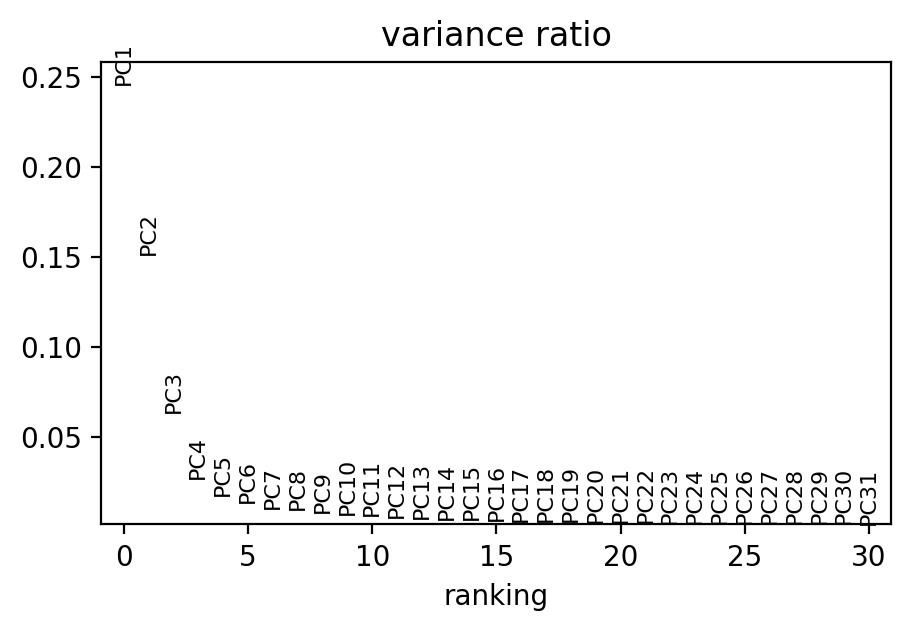

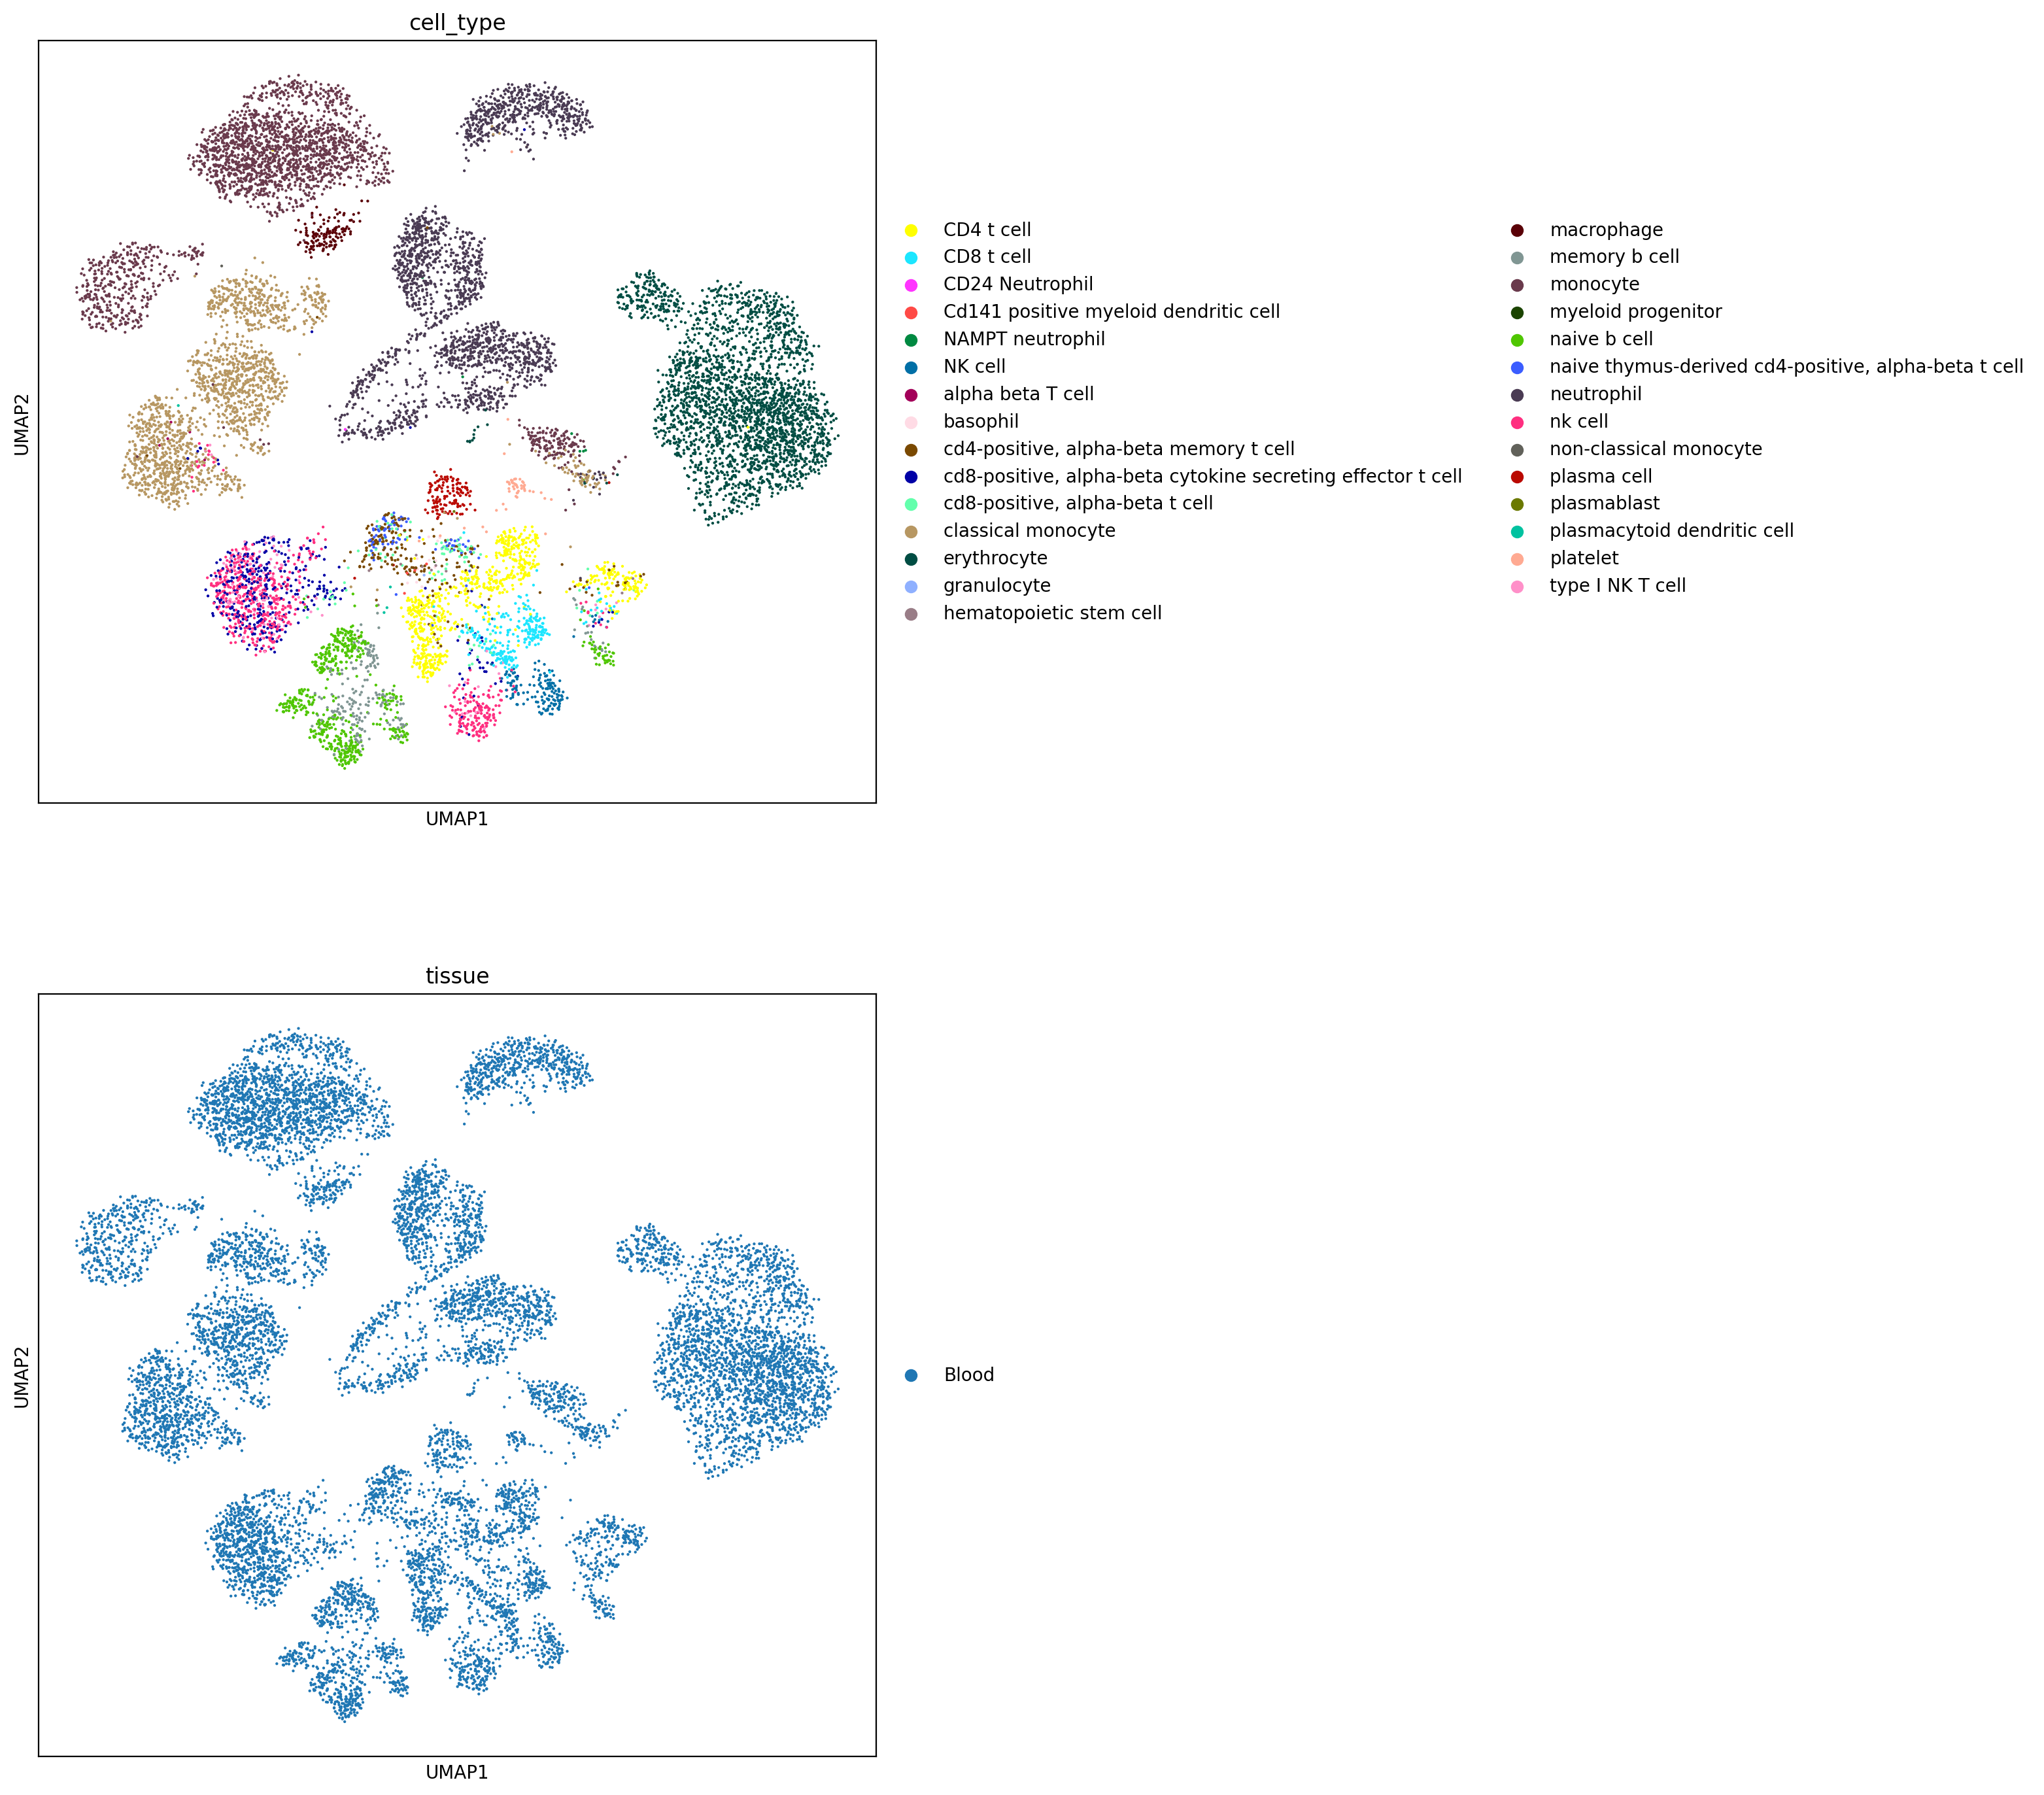

AnnData object with n_obs × n_vars = 12528 × 1500
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'cell_type', 'tissue', 'n_counts', 'UMAP 1', 'UMAP 2'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'umap', 'log1p', 'pca', 'cell_type_colors', 'tissue_colors'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    varm: 'PCs'
    layers: 'decontXcounts', 'raw_counts', 'raw'
  

In [7]:
INPUT_SIZE = 1500
sc.pp.highly_variable_genes(
    adata, 
    n_top_genes=INPUT_SIZE,
    batch_key='cell_type'
)

# ONLY keep HVGs
adata = adata[:,adata.var["highly_variable"] == True].copy()


sc.pp.pca(
    adata,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sc.pl.pca_variance_ratio(
    adata
)

sc.pp.neighbors(
    adata,
    n_neighbors=55,
)

sc.tl.umap(
    adata,
    min_dist=1.1,
)


adata.obs['UMAP 1'] = adata.obsm['X_umap'][:, 0]
adata.obs['UMAP 2'] = adata.obsm['X_umap'][:, 1]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 8

sc.pl.umap(
    adata,
    ncols=1,
    color=['cell_type', 'tissue']
)

adata

In [8]:
# break

In [9]:
adata.obs['cell_type'].value_counts()

cell_type
erythrocyte                                                    2634
monocyte                                                       2239
neutrophil                                                     2104
classical monocyte                                             1743
CD4 t cell                                                      737
nk cell                                                         620
naive b cell                                                    559
cd8-positive, alpha-beta cytokine secreting effector t cell     385
CD8 t cell                                                      246
cd4-positive, alpha-beta memory t cell                          218
memory b cell                                                   205
NK cell                                                         158
macrophage                                                      132
type I NK T cell                                                130
plasma cell                           

In [10]:
celnet = cn.CellNet(
    adata=adata,
    label_column='cell_type',
    source_label='hematopoietic stem cell',
    target_label='macrophage',
    graph_n_components=25,
    distance_metric='cosine',
    graph_neighbors=55,
    verbose=True,
)

paths = celnet.get_random_paths(n_paths=2)
paths[0]

Neighbors calculation time: 6.8744 seconds
Graph creation time: 1.6512 seconds
Graph with 12528 nodes and 482516 edges
Graph built.

Path 1 (8 nodes) generated in 1.3283 seconds.
Path 2 (5 nodes) generated in 1.1088 seconds.


['AGGCATTTCAGCGCGT_TSP10_Blood_NA_10X_2_1_Whole',
 'TGTTGAGCAGCTCCTT_TSP2_Blood_NA_10X_2_1',
 'TGAGCCGTCCAAATGC_TSP2_Blood_NA_10X_1_5_5prime',
 'TGTTCCGAGTGGGATC_TSP2_Blood_NA_10X_1_4_5prime',
 'GACGGCTGTTCCGGCA_TSP2_Blood_NA_10X_1_5_5prime',
 'ATGAGGGGTCTAAACC_TSP2_Blood_NA_10X_1_4_5prime',
 'CGACCTTCAGGCTGAA_TSP2_Blood_NA_10X_1_4_5prime',
 'GGACGTCAGGACAGAA_TSP2_Blood_NA_10X_1_4_5prime']

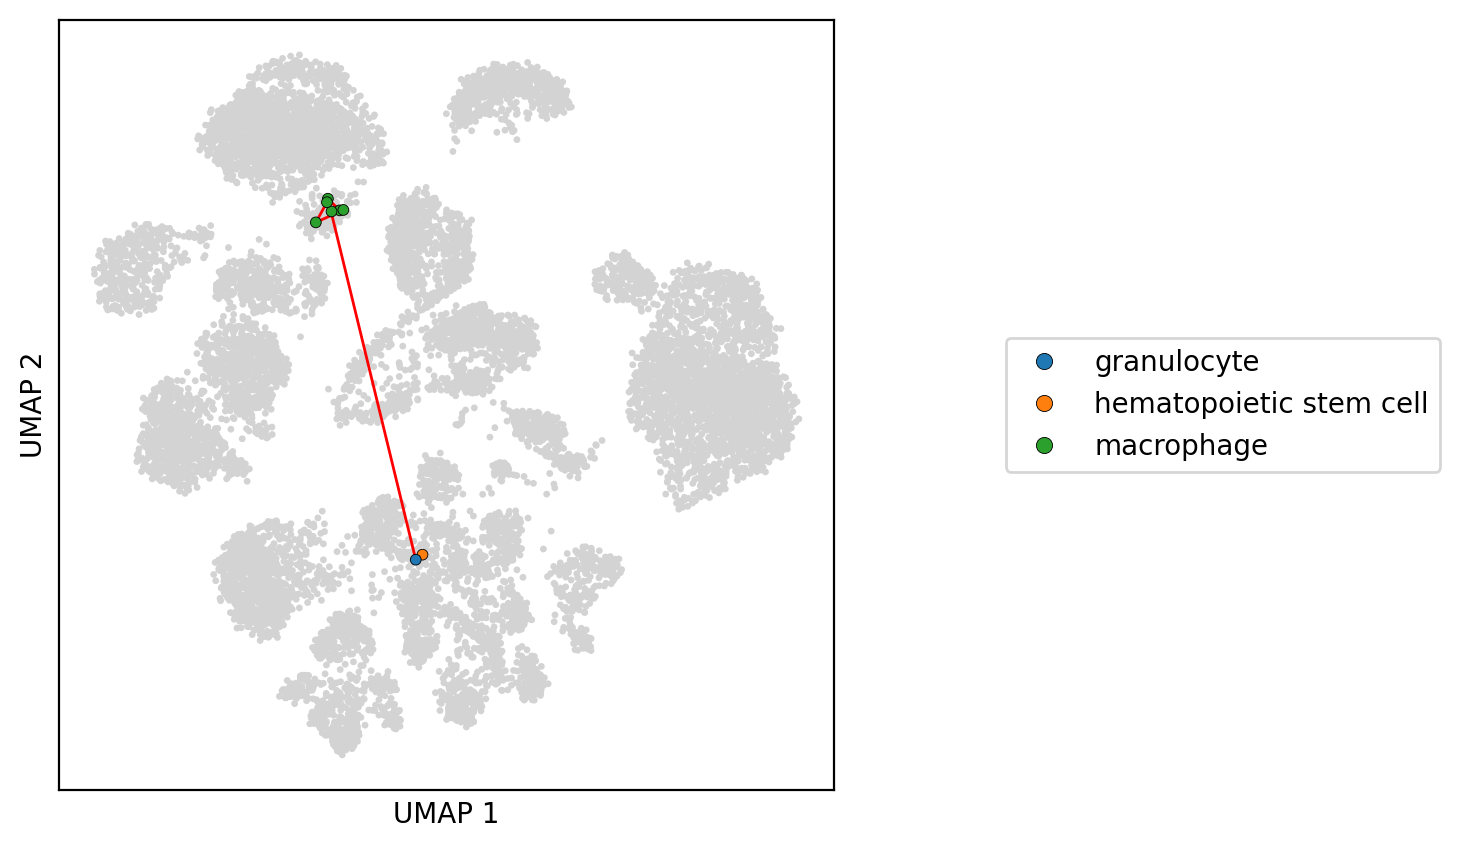

In [11]:
# extrtact and plot a single "trajectory"
traj = adata[paths[0], :].copy()
traj.obs['step'] = range(1, len(paths[0]) + 1 )


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(
    x=adata.obsm['X_umap'][:, 0],
    y=adata.obsm['X_umap'][:, 1],
    s=6,
    c='lightgrey',
    ec='none',
)

sns.scatterplot(
    data=traj.obs,
    x='UMAP 1',
    y='UMAP 2',
    s=15,
    hue='cell_type',
    # palette='Reds',
    ec='k',
    zorder=5,
)

for i in range(len(traj.obs) - 1):
    plt.plot(
        [traj.obs['UMAP 1'].iloc[i], traj.obs['UMAP 1'].iloc[i + 1]],
        [traj.obs['UMAP 2'].iloc[i], traj.obs['UMAP 2'].iloc[i + 1]],
        color='red',
        linewidth=1,
        zorder=4, # keep lines behind the scatter points
    )

plt.xticks([])
plt.yticks([])

sns.move_legend(
    plt.gca(),
    title='',
    loc='center right',
    markerscale=1.5,
    bbox_to_anchor=(1.8, 0.5),
)

# Build trainning data

In [12]:
paths = celnet.get_random_paths(n_paths=1)
path = paths[0]
first_paths = path[:-1]
last_paths = path[1:]

traj = adata[path, :].copy()
traj.obs['step'] = range(1, len(path) + 1 )

X = adata[first_paths, :].X.todense().copy()
Y = adata[last_paths, :].X.todense().copy()

print(f"{X.shape=}")
print(f"{Y.shape=}")

traj.obs.head()

Path 1 (5 nodes) generated in 0.9600 seconds.
X.shape=(4, 1500)
Y.shape=(4, 1500)


,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,cell_type,tissue,n_counts,UMAP 1,UMAP 2,step
cell_id,,,,,,,,,,,,,,,,,
CCGTAGGCAGGAGGTT_TSP7_Blood_NA_10X_1_1,Blood,10X,TSP7,nan,47342.0,7527,hematopoietic stem cell,hematopoietic stem cell,True,immune,female,hematopoietic stem cell,Blood,48062.0,0.468668,-0.029310,1
CAAGACTAGCATACTC_TSP2_Blood_NA_10X_1_3,Blood,10X,TSP2,nan,12232.0,3066,myeloid progenitor,myeloid progenitor,True,immune,female,myeloid progenitor,Blood,12587.0,1.282348,-0.333023,2
TGTTGAGCAGCTCCTT_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,10271.0,2382,granulocyte,granulocyte,True,immune,female,granulocyte,Blood,17460.0,0.820245,-0.955261,3
TGTCCCAGTGCACGAA_TSP2_Blood_NA_10X_1_4_5prime,Blood,10X,TSP2,nan,2914.0,1173,macrophage,macrophage,True,immune,female,macrophage,Blood,2914.0,-2.500114,15.076033,4
AAGGAGCAGCACCGCT_TSP2_Blood_NA_10X_1_4_5prime,Blood,10X,TSP2,nan,2631.0,1195,macrophage,macrophage,True,immune,female,macrophage,Blood,2634.0,-3.900033,14.288170,5


In [13]:
# break

# Train

/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Prediction shape: torch.Size([4, 1500])


Text(0.5, 1.0, 'Training Loss')

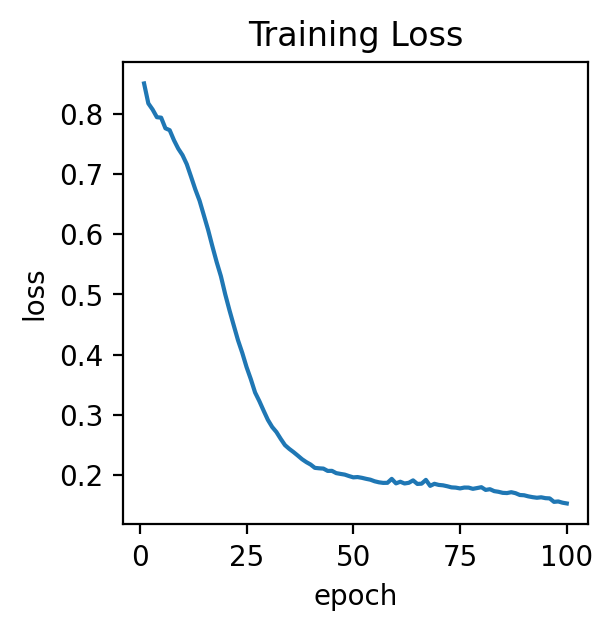

In [14]:
# Example usage:
input_size = X.shape[1]
hidden_size = 128
output_size = X.shape[1]

model = nc.NextCell(input_size, hidden_size, output_size)

# Example data (replace with your actual data)
input_gene_expression = torch.tensor(X)
target_gene_expression = torch.tensor(Y)

loss = model.train_model(input_gene_expression, target_gene_expression, epochs=100)

# Example prediction:
prediction = model.predict(input_gene_expression)
print("Prediction shape:", prediction.shape)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sns.lineplot(
    data=loss,
    x='epoch',
    y='loss',
)

plt.title('Training Loss')

# Plot the expression

In [15]:
# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 8, 2

# input_df =  pd.DataFrame(
#         input_gene_expression, 
#         columns=adata.var_names,
#     )

# pred_df =  pd.DataFrame(
#         prediction, 
#         columns=adata.var_names,
#     )

# sample_cols = np.random.choice(adata.var_names, 25, replace=False)

# sns.heatmap(
#    input_df[sample_cols]
# )
# plt.yticks([])
# plt.title('input expression')
# plt.xlabel('')
# plt.show()

# sns.heatmap(
#    pred_df[sample_cols]
# )
# plt.yticks([])
# plt.xlabel('')
# plt.title('predicted expression')
# plt.show()

# How does it generalize?

Path 1 (5 nodes) generated in 1.2967 seconds.
           input    target      pred
input   1.000000  0.808471  0.480599
target  0.808471  1.000000  0.571743
pred    0.480599  0.571743  1.000000


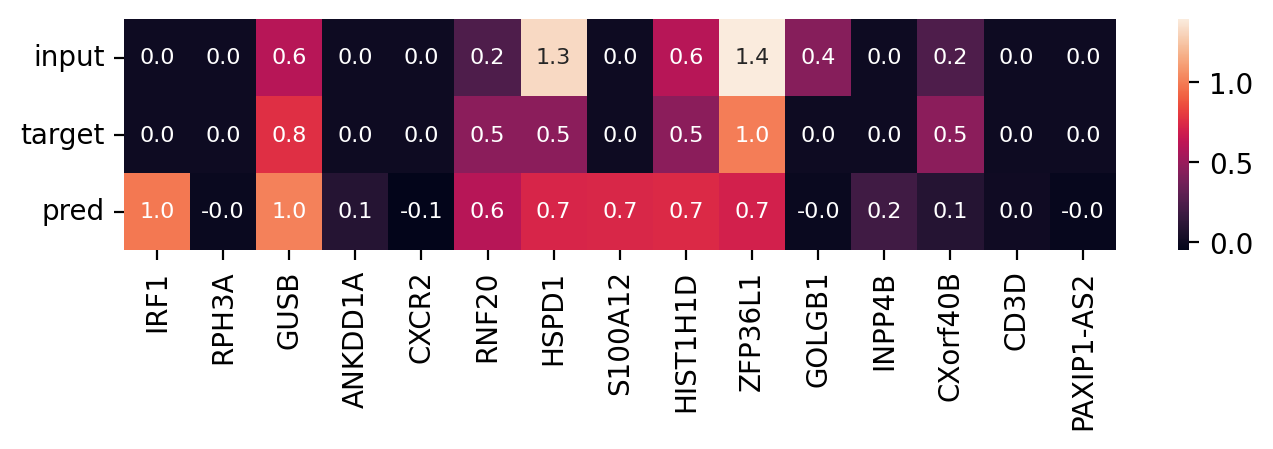

In [16]:
paths = celnet.get_random_paths(n_paths=1)
path = paths[0]

cell_1 = adata[path[0], :].X.todense().copy()
cell_2 = adata[path[1], :].X.todense().copy()

# # Example prediction:
prediction = model.predict(
    torch.tensor(cell_1),
)

sample_cols = np.random.choice(adata.var_names, 15, replace=False)

input = pd.DataFrame(
    cell_1, 
    columns=adata.var_names,
)

pred = pd.DataFrame(
    prediction, 
    columns=adata.var_names,
)


output = pd.DataFrame(
    cell_2, 
    columns=adata.var_names,
)

vis = pd.concat([input, output, pred])
vis.index = ['input', 'target', 'pred' ]


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 1.5

sns.heatmap(
    vis[sample_cols],
    annot=True,
    fmt=".1f", 
    annot_kws={"size": 8}, 
)

plt.gca().tick_params(axis='y', rotation=0)

print(vis[sample_cols].T.corr())

# Embeddings

In [17]:
tf_list_path = "/nfs/turbo/umms-indikar/shared/projects/DGC/data/scenic/tf_lists/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(tf_list_path)]
print(f"{len(tf_list)=}")
tf_list[:20]

len(tf_list)=1892


['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1',
 'ZNF232',
 'ZNF282',
 'ZNF410',
 'ZSCAN16',
 'ZNF524',
 'ZNF713',
 'ZNF75A',
 'ZSCAN4',
 'ZNF200',
 'SNAI2']

In [18]:
adata.var.head()

,gene_symbol,feature_type,ensemblid,highly_variable,means,dispersions,dispersions_norm,mean,std,n_counts,highly_variable_nbatches,highly_variable_intersection
MTND1P23,MTND1P23,Gene Expression,ENSG00000225972.1,True,0.579447,0.049360,0.423903,0.651838,1.081995,40972.0,6,False
MTATP6P1,MTATP6P1,Gene Expression,ENSG00000248527.1,True,1.669713,-0.020914,0.387225,1.587537,1.054957,67074.0,6,False
HES4,HES4,Gene Expression,ENSG00000188290.10,True,0.018912,0.480514,0.277383,0.181951,0.471181,569.0,6,False
ISG15,ISG15,Gene Expression,ENSG00000187608.9,True,0.296301,-0.676726,0.387396,0.249824,0.523513,12721.0,5,False
TNFRSF18,TNFRSF18,Gene Expression,ENSG00000186891.14,True,0.176865,0.361915,0.302043,0.051677,0.260355,1734.0,5,False


emb.shape=torch.Size([4, 1500])


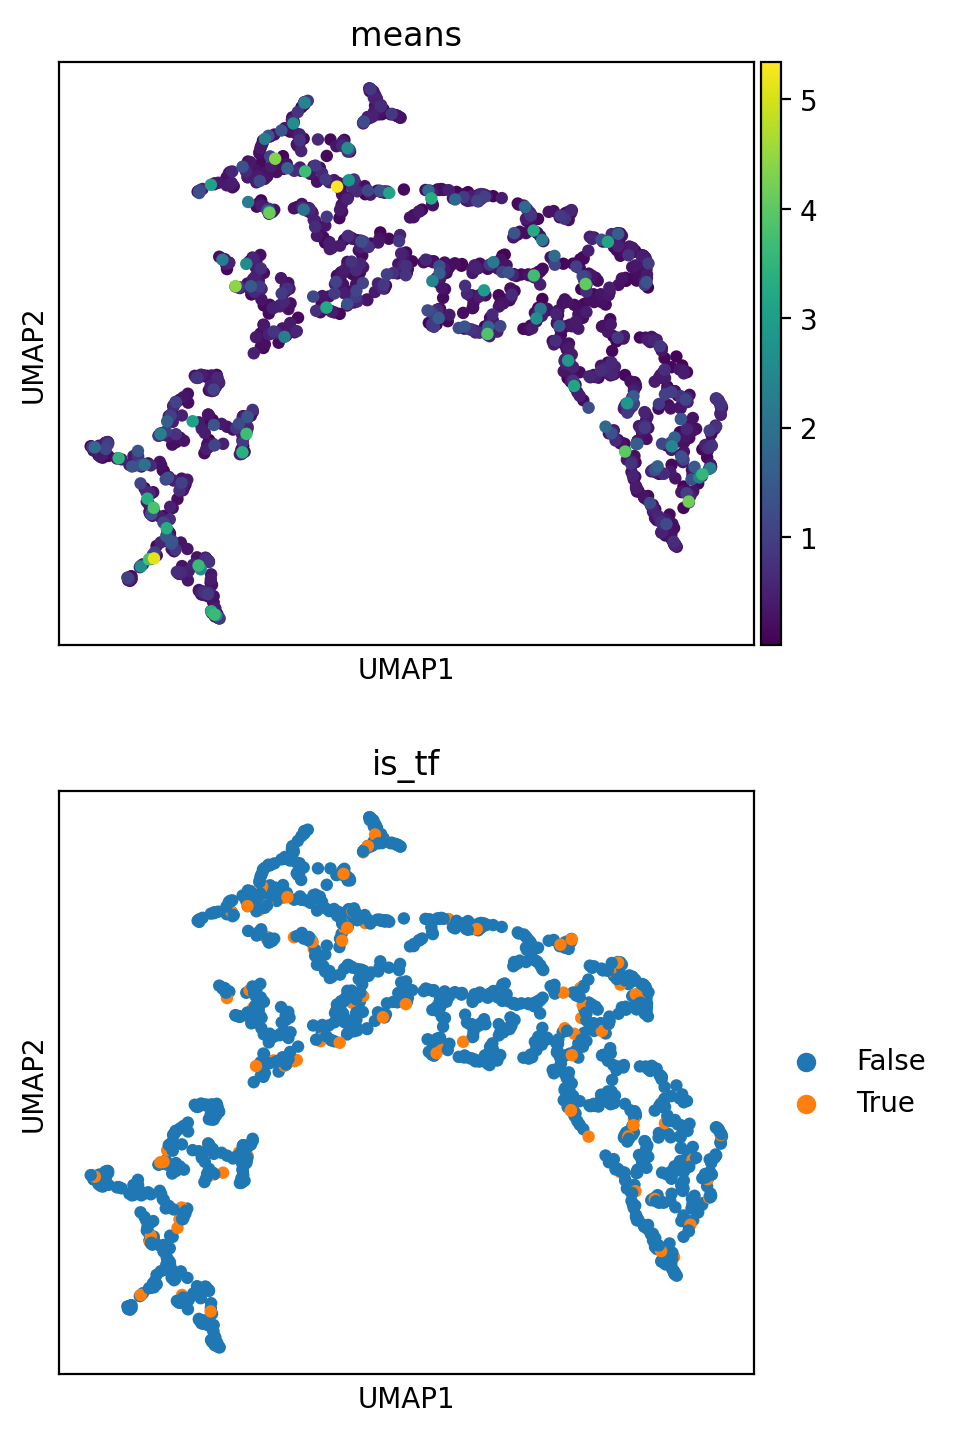

AnnData object with n_obs × n_vars = 1500 × 4
    obs: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts', 'highly_variable_nbatches', 'highly_variable_intersection', 'gene_name', 'is_tf'
    uns: 'neighbors', 'umap', 'is_tf_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

In [19]:
emb = model.get_embeddings(input_gene_expression)
print(f"{emb.shape=}")

edata = an.AnnData(
    emb.detach().numpy().T, 
    obs=adata.var,
)

edata.obs['gene_name'] = edata.obs_names
edata.obs['is_tf'] = edata.obs['gene_name'].isin(tf_list)

sc.pp.neighbors(
    edata,
    n_neighbors=10,
)

sc.tl.umap(
    edata,
    min_dist=0.15,
)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    edata,
    ncols=1,
    color=['means', 'is_tf'],
)

edata

# Larger Example

In [20]:
celnet = cn.CellNet(
    adata=adata,
    label_column='cell_type',
    source_label='hematopoietic stem cell',
    target_label='macrophage',
    graph_n_components=25,
    distance_metric='cosine',
    graph_neighbors=50,
    verbose=False,
)

paths = celnet.get_random_paths(n_paths=50)
print('done')

done


In [21]:
""" No Sampling - adjacent cells only """
X = []
Y = []

for path in paths:
    first_paths = path[:-1]
    last_paths = path[1:]
    
    x_traj = adata[first_paths, :].X.todense().copy()
    y_traj = adata[last_paths, :].X.todense().copy()
    
    X.append(x_traj)
    Y.append(y_traj)

X = np.vstack(X)
Y = np.vstack(Y)
print(f"{X.shape=}")
print(f"{Y.shape=}")

X.shape=(290, 1500)
Y.shape=(290, 1500)


/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Prediction shape: torch.Size([290, 1500])


<Axes: xlabel='epoch', ylabel='loss'>

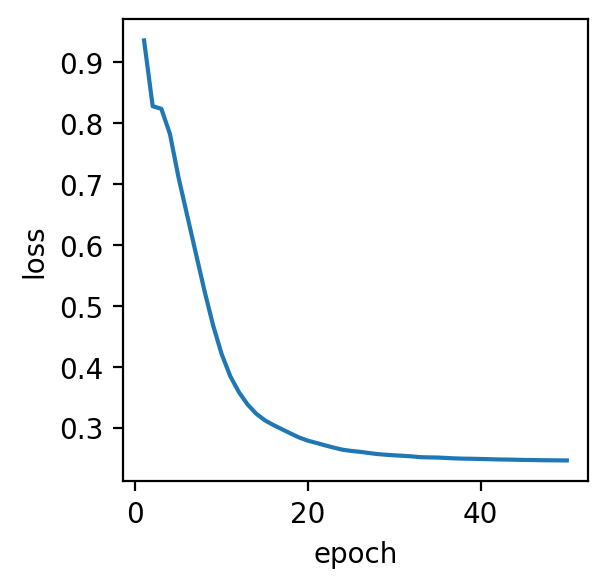

In [22]:
input_size = traj.shape[1]
hidden_size = 256
output_size = traj.shape[1]

model = nc.NextCell(
    input_size, 
    hidden_size, 
    output_size,
)

loss = model.train_model(
    torch.tensor(X),
    torch.tensor(Y), 
    epochs=50,
)

# Example prediction:
prediction = model.predict(torch.tensor(X))
print("Prediction shape:", prediction.shape)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sns.lineplot(
    data=loss,
    x='epoch',
    y='loss',
)

11
           input    target      pred
input   1.000000 -0.243306  0.087149
target -0.243306  1.000000  0.056786
pred    0.087149  0.056786  1.000000


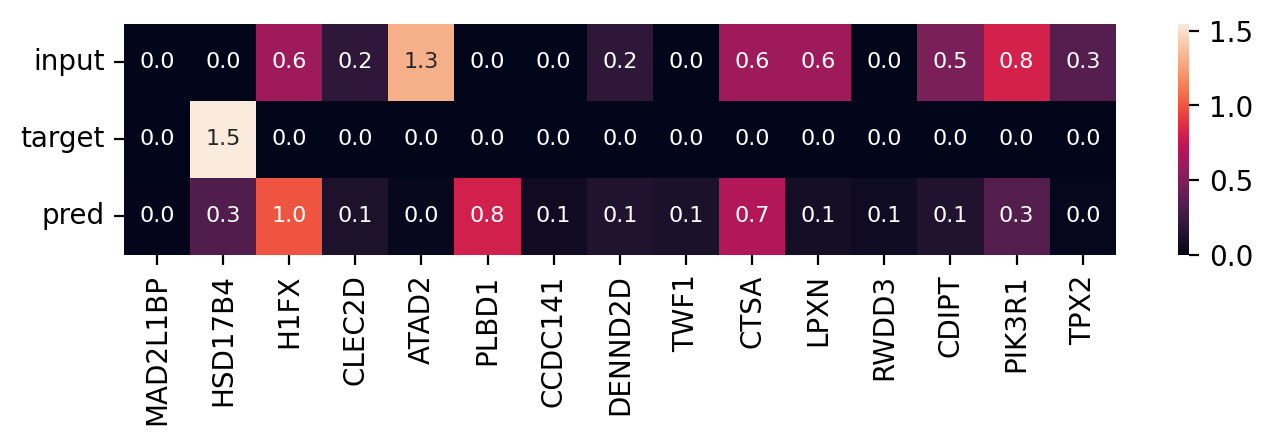

In [23]:
paths = celnet.get_random_paths(n_paths=1)
path = paths[0]
print(f"{len(path)}")

cell_1 = adata[path[0], :].X.todense().copy()
cell_2 = adata[path[1], :].X.todense().copy()

# # Example prediction:
prediction = model.predict(
    torch.tensor(cell_1),
)

sample_cols = np.random.choice(adata.var_names, 15, replace=False)

input = pd.DataFrame(
    cell_1, 
    columns=adata.var_names,
)

pred = pd.DataFrame(
    prediction, 
    columns=adata.var_names,
)


output = pd.DataFrame(
    cell_2, 
    columns=adata.var_names,
)

vis = pd.concat([input, output, pred])
vis.index = ['input', 'target', 'pred' ]


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 1.5

sns.heatmap(
    vis[sample_cols],
    annot=True,
    fmt=".1f", 
    annot_kws={"size": 8}, 
)

plt.gca().tick_params(axis='y', rotation=0)

print(vis[sample_cols].T.corr())

# Quantify

result.shape=(381, 4)


,input_cell_type,distance,correlation,MSE
0,hematopoietic stem cell,22.411222,0.700487,0.334842
1,hematopoietic stem cell,16.136506,0.852376,0.173591
2,granulocyte,17.660609,0.843781,0.207931
3,monocyte,16.914631,0.861941,0.190736
4,monocyte,16.900133,0.862522,0.190410


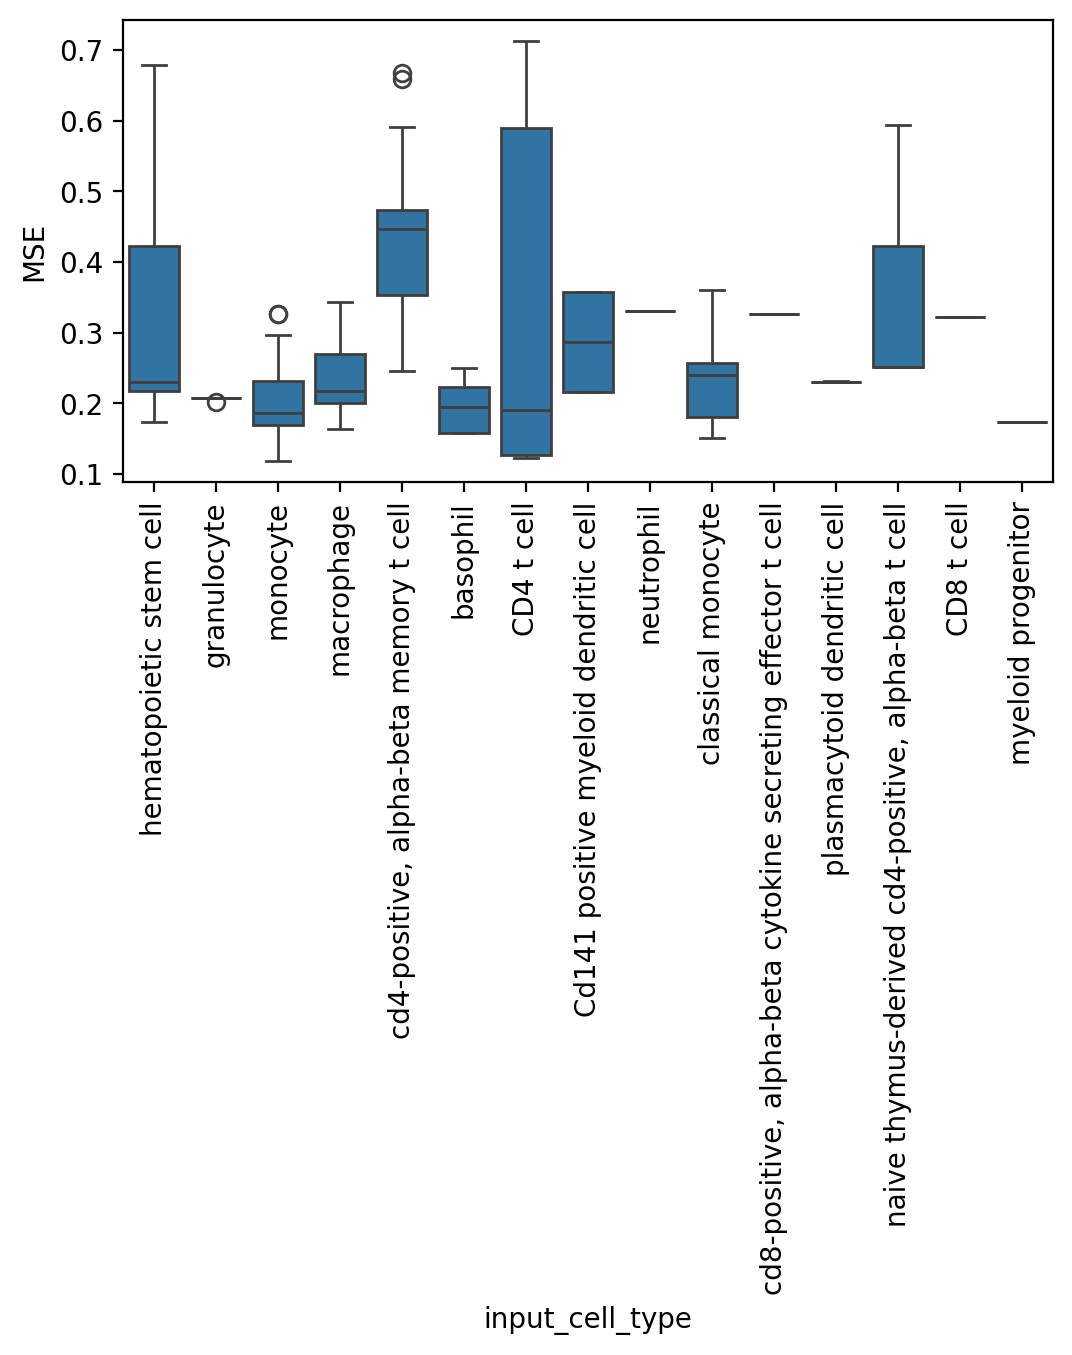

In [30]:
paths = celnet.get_random_paths(n_paths=25)

result = []

for path in paths:
    traj = adata[path, :].copy()
    y_true = traj.X.todense()
    y_pred = model.predict(
        torch.tensor(y_true),
    ).detach().numpy()

    for i in range(len(path)-1):
        y_eval = np.vstack([y_true[i+1, :], y_pred[i, :]])
        d = pdist(y_eval, metric='euclidean')[0]


        row = {
            'input_cell_type' : traj[path[i], :].obs['cell_type'].values[0],
            'distance' : pdist(y_eval, metric='euclidean')[0],
            'correlation' : 1 - pdist(y_eval, metric='correlation')[0],
            'MSE' : mean_squared_error(np.ravel(y_true[i+1, :]), y_pred[i, :]),
        }
        result.append(row)
        

result = pd.DataFrame(result)
print(f"{result.shape=}")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3

sns.boxplot(
    data=result,
    x='input_cell_type',
    y='MSE'
)

plt.gca().tick_params(axis='x', rotation=90)
result.head()

# Longer windows

In [25]:
celnet = cn.CellNet(
    adata=adata,
    label_column='cell_type',
    source_label='hematopoietic stem cell',
    target_label='macrophage',
    graph_n_components=20,
    distance_metric='euclidean',
    graph_neighbors=7,
    verbose=False,
)

paths = celnet.get_random_paths(n_paths=50)
print('done')

done


In [33]:
""" windows """
windows = [1, 2, 3, 4]
X = []
Y = []

Xobs = []
Yobs = []

for i, path in enumerate(paths):

    for window_size in windows:
        if not len(path) - window_size > 2:
            continue 
            
        input_path = path[:-window_size]
        output_path = path[window_size:]

        xdata = adata[input_path, :].copy()
        ydata = adata[output_path, :].copy()

        xdata.obs['path'] = i + 1
        ydata.obs['path'] = i + 1

        X.append(xdata.X.todense())
        Y.append(ydata.X.todense())

        Xobs.append(xdata.obs.copy())
        Yobs.append(ydata.obs.copy())

        
X = np.vstack(X)
Y = np.vstack(Y)
print(f"{X.shape=}")
print(f"{Y.shape=}")

Xobs = pd.concat(Xobs)
Yobs = pd.concat(Yobs)

print(f"{Xobs.shape=}")
print(f"{Yobs.shape=}")

Yobs.head()

X.shape=(1374, 1500)
Y.shape=(1374, 1500)
Xobs.shape=(1374, 17)
Yobs.shape=(1374, 17)


,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,cell_type,tissue,n_counts,UMAP 1,UMAP 2,path
cell_id,,,,,,,,,,,,,,,,,
AAGACCTCAATGAAAC_TSP2_Blood_NA_10X_1_4_5prime,Blood,10X,TSP2,nan,4941.0,1629,hematopoietic stem cell,hematopoietic stem cell,True,immune,female,hematopoietic stem cell,Blood,4941.0,1.793068,-0.769969,1
TGTTGAGCAGCTCCTT_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,10271.0,2382,granulocyte,granulocyte,True,immune,female,granulocyte,Blood,17460.0,0.820245,-0.955261,1
AAGTCGTGTTGCATAC_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,6694.0,1940,monocyte,monocyte,True,immune,female,monocyte,Blood,6695.0,-1.721430,17.157772,1
AGGGTGACATAGAATG_TSP2_Blood_NA_10X_1_3,Blood,10X,TSP2,nan,9705.0,2467,monocyte,monocyte,True,immune,female,monocyte,Blood,9707.0,-1.695434,17.297894,1
GTTGCGGAGATGAATC_TSP2_Blood_NA_10X_1_3,Blood,10X,TSP2,nan,8555.0,2561,monocyte,monocyte,True,immune,female,monocyte,Blood,8720.0,-2.800377,17.854094,1


/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Prediction shape: torch.Size([1374, 1500])


<Axes: xlabel='epoch', ylabel='loss'>

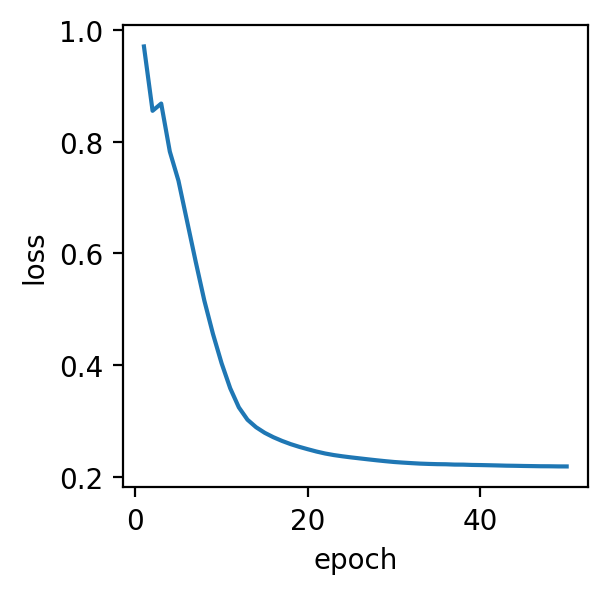

In [34]:
input_size = traj.shape[1]
hidden_size = 256
output_size = traj.shape[1]

model = nc.NextCell(
    input_size, 
    hidden_size, 
    output_size,
)

loss = model.train_model(
    torch.tensor(X),
    torch.tensor(Y), 
    epochs=50,
)

# Example prediction:
prediction = model.predict(torch.tensor(X))
print("Prediction shape:", prediction.shape)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sns.lineplot(
    data=loss,
    x='epoch',
    y='loss',
)

torch.Size([1374, 1500])

In [ ]:
break

In [ ]:
emb = model.get_embeddings(input_gene_expression)
print(f"{emb.shape=}")

edata = an.AnnData(
    emb.detach().numpy().T, 
    obs=adata.var,
)

edata.obs['gene_name'] = edata.obs_names
edata.obs['is_tf'] = edata.obs['gene_name'].isin(tf_list)

sc.pp.neighbors(
    edata,
    n_neighbors=10,
)

sc.tl.umap(
    edata,
    min_dist=0.15,
)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    edata,
    ncols=1,
    color=['means', 'is_tf'],
)

edata

In [ ]:
break

In [ ]:
paths = celnet.get_random_paths(n_paths=1)
path = paths[0]
print(f"{len(path)}")

cell_1 = adata[path[0], :].X.todense().copy()
cell_2 = adata[path[1], :].X.todense().copy()

# # Example prediction:
prediction = model.predict(
    torch.tensor(cell_1),
)

gene_list = adata.var[adata.var['gene_symbol'].isin(tf_list)]['gene_symbol'].values
sample_cols = np.random.choice(gene_list, 20, replace=False)

input = pd.DataFrame(
    cell_1, 
    columns=adata.var_names,
)

pred = pd.DataFrame(
    prediction, 
    columns=adata.var_names,
)


output = pd.DataFrame(
    cell_2, 
    columns=adata.var_names,
)

vis = pd.concat([input, output, pred])
vis.index = ['input', 'target', 'pred' ]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 1.5

sns.heatmap(
    vis[sample_cols],
    annot=True,
    fmt=".1f", 
    annot_kws={"size": 8}, 
)

plt.gca().tick_params(axis='y', rotation=0)

print(vis[sample_cols].T.corr())

In [ ]:
adata.var.head()

In [ ]:
break

In [ ]:
# paths = cn.get_random_paths(n_paths=1)
# path = paths[0]
# print(f"{len(path)}")


# traj = adata[path, :].copy()
# PRE

# sc.pp.neighbors(traj)
# sc.tl.umap(traj)

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 6, 6

# sc.pl.umap(traj, size=150, color=['cell_type'])

In [ ]:
break

In [ ]:
def sample_pairs_arrays(numbers, n):
    """
    Samples n pairs (i, j) randomly from a list of integers, where i < j,
    and returns two NumPy arrays, one with i values and one with j values.

    Args:
        numbers (list of int): List of integers to sample from.
        n (int): Number of pairs to sample.

    Returns:
        tuple of numpy.ndarray: Two NumPy arrays, one with i values and one with j values.
    """
    num_numbers = len(numbers)
    i_indices = np.random.choice(num_numbers, size=n)
    j_indices = np.random.choice(num_numbers, size=n)

    i_values = np.array(numbers)[i_indices]
    j_values = np.array(numbers)[j_indices]

    # Ensure i < j
    mask = i_values >= j_values
    while np.any(mask):
        j_values[mask] = np.array(numbers)[np.random.choice(num_numbers, size=np.sum(mask))]
        mask = i_values >= j_values

    return i_values, j_values

In [ ]:
n_paths = 25
sample_factor = 3 # from each path

X = []
Y = []

for i in range(n_paths):
    # Find a path between cell types 'A' and 'B'
    start_time = time.time()
    path = network.a_star(
        source_type=source_type,
        target_type=target_type,
    )
    end_time = time.time()

    steps = {k: i for i, k in enumerate(path)}
    idx_list = list(steps.values())

    # PAIR RANDOM CELLS FROM THE SAME PATH
    x_idx, y_idx = sample_pairs_arrays(idx_list, int(sample_factor*len(path)))
    print(f"Path {i + 1} (len={len(path)}): Pathfinding took: {end_time - start_time:.4f} seconds")

    # subset trajectories
    x_traj = adata.X[x_idx, :].todense().copy()
    y_traj = adata.X[y_idx, :].todense().copy()

    print(f"{x_traj.shape=} {type(x_traj)} {y_traj.shape=} {type(y_traj)}")
    X.append(x_traj)
    Y.append(y_traj)
    # break

X = np.vstack(X)
Y = np.vstack(Y)
print(f"{X.shape=}")
print(f"{Y.shape=}")

In [ ]:
input_size = traj.shape[1]
hidden_size = 128
output_size = traj.shape[1]

model = NextCell(input_size, hidden_size, output_size)

# Example data (replace with your actual data)
input_gene_expression = torch.tensor(X)
target_gene_expression = torch.tensor(Y)

print(f"{input_gene_expression.shape=}")
print(f"{target_gene_expression.shape=}")

loss = model.train_model(input_gene_expression, target_gene_expression, epochs=1000)

# Example prediction:
prediction = model.predict(input_gene_expression)
print("Prediction shape:", prediction.shape)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sns.lineplot(
    data=loss,
    x='epoch',
    y='loss',
)

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 4

input_df =  pd.DataFrame(
        input_gene_expression, 
        columns=adata.var_names,
    )

pred_df =  pd.DataFrame(
        prediction, 
        columns=adata.var_names,
    )

sample_cols = np.random.choice(adata.var_names, 25, replace=False)

sns.heatmap(
   input_df[sample_cols]
)
plt.yticks([])
plt.title('input expression')
plt.xlabel('')
plt.show()

sns.heatmap(
   pred_df[sample_cols]
)
plt.yticks([])
plt.xlabel('')
plt.title('predicted expression')
plt.show()

In [ ]:
tf_list_path = "/nfs/turbo/umms-indikar/shared/projects/DGC/data/scenic/tf_lists/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(tf_list_path)]
print(f"{len(tf_list)=}")
tf_list[:20]

In [ ]:
emb = model.get_embeddings(input_gene_expression)
print(f"{emb.shape=}")

edata = an.AnnData(
    emb.detach().numpy().T, 
    obs=adata.var,
)

edata.obs['gene_name'] = edata.obs_names
edata.obs['is_tf'] = edata.obs['gene_name'].isin(tf_list)

sc.pp.neighbors(
    edata,
)

sc.tl.umap(
    edata,
    min_dist=0.15,
)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    edata,
    ncols=1,
    color=['means', 'is_tf'],
)

edata

In [ ]:
break

In [ ]:
break

In [ ]:
adata.obs['cell_type'].value_counts()

In [ ]:
break

In [ ]:
def anndata_to_networkx(adata):
  """
  Converts an AnnData object with precomputed connectivities and distances 
  to a networkX graph. Adds all entries in adata.obs as node attributes.

  Args:
    adata: An AnnData object with 'connectivities' and 'distances' in obsp.

  Returns:
    A networkX graph object.
  """
  graph = nx.Graph()
  
  # Add nodes with attributes from adata.obs
  for i, cell_name in enumerate(adata.obs_names):
    graph.add_node(cell_name, **adata.obs.iloc[i].to_dict())

  # Add edges based on connectivities
  rows, cols = adata.obsp['connectivities'].nonzero()
  for i, j in zip(rows, cols):
    if i < j:  # Avoid adding duplicate edges
      weight = adata.obsp['distances'][i, j]
      graph.add_edge(adata.obs_names[i], adata.obs_names[j], weight=weight)

  return graph


def get_random_nodes(adata, source_type, target_type):
  """
  Selects a random source node and a random target node from an AnnData object.
  """
  source_node = random.choice(adata.obs[adata.obs['free_annotation'] == source_type].index)
  target_node = random.choice(adata.obs[adata.obs['free_annotation'] == target_type].index)
  return source_node, target_node


def compute_distance(source_node, target_node, obsm_key='X_pca'):
    """ The Euclidean distance between the two points.
    """
    source_coords = adata[source_node, :].obsm[obsm_key]
    target_coords = adata[target_node, :].obsm[obsm_key]
    distance = np.linalg.norm(source_coords - target_coords)
    return distance



path = nx.astar_path(
    G, 
    source_node, 
    target_node,
    heuristic=compute_distance,
)



source_type = "hematopoietic stem cell"
target_type = "macrophage"
obsm_key = 'X_pca'

source_node, target_node = get_random_nodes(
    adata, 
    source_type,
    target_type,
)

